In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## factor

* `factor = actual_time / osrm_time`
* Matches 100% of rows.
* Directly derived from actual travel time.

**Decision:** Drop (data leakage).

---

## segment_factor

* `segment_factor = segment_actual_time / segment_osrm_time`
* Matches 98.4% of rows.
* Directly derived from segment actual time.

**Decision:** Drop (data leakage).

---

## is_cutoff, cutoff_factor

* Operational meaning is unclear due to lack of documentation.
* May contain useful business/process information.

**Decision:** Retain for now and evaluate through feature importance.


In [17]:
df = pd.read_csv("../data/delivery_data.csv")

In [18]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [20]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [21]:
df_test = df[df['data'] == 'test'].reset_index(drop=True)
df = df[df['data'] == 'training'].reset_index(drop=True)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104858 entries, 0 to 104857
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            104858 non-null  object 
 1   trip_creation_time              104858 non-null  object 
 2   route_schedule_uuid             104858 non-null  object 
 3   route_type                      104858 non-null  object 
 4   trip_uuid                       104858 non-null  object 
 5   source_center                   104858 non-null  object 
 6   source_name                     104729 non-null  object 
 7   destination_center              104858 non-null  object 
 8   destination_name                104758 non-null  object 
 9   od_start_time                   104858 non-null  object 
 10  od_end_time                     104858 non-null  object 
 11  start_scan_to_end_scan          104858 non-null  float64
 12  is_cutoff       

In [23]:
df.drop(columns=['factor', 'is_cutoff', 'cutoff_factor', 
                 'segment_factor', 'cutoff_timestamp'], inplace=True)

#### Null exists only in source_name and destination_name

In [24]:
df['source_name'].fillna('Unknown', inplace=True)
df['destination_name'].fillna('Unknown', inplace=True)

C:\Users\prakh\AppData\Local\Temp\ipykernel_32540\1905193127.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['source_name'].fillna('Unknown', inplace=True)
C:\Users\prakh\AppData\Local\Temp\ipykernel_32540\1905193127.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [25]:
df.head(2)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,10.435660,14.0,11.0,11.9653,14.0,11.0,11.9653
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,18.936842,24.0,20.0,21.7243,10.0,9.0,9.7590


In [26]:
df['od_start_time'] = pd.to_datetime(df['od_start_time'])

df['hour_of_day'] = df['od_start_time'].dt.hour
df['day_of_week'] = df['od_start_time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

def time_bin(hour):
    if 6 <= hour < 12:
        return 'morning_peak'
    elif 12 <= hour < 18:
        return 'midday'
    elif 18 <= hour < 23:
        return 'evening_peak'
    else:
        return 'overnight'

df['time_bin'] = df['hour_of_day'].apply(time_bin)

In [ ]:
df['segment_key'] = (df['trip_uuid'] + '_' + df['source_center'] + '_' + df['destination_center'])
df.sort_values(['segment_key', 'od_start_time'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [35]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,hour_of_day,day_of_week,is_weekend,time_bin,segment_key
0,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,33.0,38.0620,50.0,33.0,38.0620,16,2,0,midday,trip-153671041653548748_IND209304AAA_IND000000ACB
1,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,41.0,49.0540,9.0,8.0,10.9921,16,2,0,midday,trip-153671041653548748_IND209304AAA_IND000000ACB
2,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,64.0,79.6849,34.0,22.0,30.6308,16,2,0,midday,trip-153671041653548748_IND209304AAA_IND000000ACB
3,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,81.0,104.7807,25.0,17.0,25.0959,16,2,0,midday,trip-153671041653548748_IND209304AAA_IND000000ACB
4,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,96.0,125.8196,20.0,14.0,21.0389,16,2,0,midday,trip-153671041653548748_IND209304AAA_IND000000ACB


In [36]:
df['cumulative_actual_time'] = df.groupby('segment_key')['segment_actual_time'].cumsum()
df['cumulative_osrm_time']   = df.groupby('segment_key')['segment_osrm_time'].cumsum()
df['cumulative_osrm_dist']   = df.groupby('segment_key')['segment_osrm_distance'].cumsum()

In [45]:

df = df.sort_values(['trip_uuid', 'source_center', 'destination_center', 'od_start_time'])
df['segment_key'] = df['trip_uuid'] + '_' + df['source_center'] + '_' + df['destination_center']

# segment_df - take last row per corridor (final cumulative value)
segment_df = df.groupby('segment_key').last().reset_index()
# actual_time on last row = total time for that corridor ✓

# This gives you one row per corridor per trip
# with the total actual time, osrm time, distance for that corridor

In [46]:
# trip_df - sum the corridor finals per trip
trip_df = segment_df.groupby('trip_uuid').agg(
    route_type        = ('route_type', 'first'),
    origin            = ('source_center', 'first'),
    destination       = ('destination_center', 'last'),
    total_actual_time = ('actual_time', 'sum'),  # sum corridor finals
    total_osrm_time   = ('osrm_time', 'sum'),
    total_distance    = ('actual_distance_to_destination', 'sum'),
    hour_of_day       = ('hour_of_day', 'first'),
    day_of_week       = ('day_of_week', 'first'),
    is_weekend        = ('is_weekend', 'first'),
    time_bin          = ('time_bin', 'first')
).reset_index()

## Processed Datasets

### `segment_df` (Corridor-Level Data)

One row represents one corridor (edge) between two logistics hubs.

| Source       | Destination  | Cumulative Actual | Cumulative OSRM |
| ------------ | ------------ | ----------------- | --------------- |
| IND388121AAA | IND388620AAB | 68 min            | 44 min          |
| IND388620AAB | IND388320AAA | 102 min           | 45 min          |

**Usage:** Graph construction and edge weighting.

* Defines edges between hubs.
* Computes corridor delay ratios.
* Used to build the NetworkX graph.

---

### `trip_df` (Trip-Level Data)

One row represents one complete trip.

| Origin       | Destination  | Total Actual | Total OSRM |
| ------------ | ------------ | ------------ | ---------- |
| IND388121AAA | IND388320AAA | 170 min      | 89 min     |

**Usage:** ETA prediction.

* Input to the XGBoost model.
* Combines route features, temporal features, and node embeddings.
* Predicts total actual trip time.


In [40]:
segment_df.head()

,segment_key,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,segment_actual_time,segment_osrm_time,segment_osrm_distance,hour_of_day,day_of_week,is_weekend,time_bin,cumulative_actual_time,cumulative_osrm_time,cumulative_osrm_dist
0,trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,20.0,10.0,15.0693,16,2,0,midday,728.0,534.0,670.6205
1,trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),...,22.0,3.0,5.3898,0,2,0,overnight,820.0,474.0,649.8528
2,trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),...,15.0,7.0,6.9464,2,2,0,overnight,46.0,26.0,28.1995
3,trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),...,20.0,3.0,3.8074,0,2,0,overnight,95.0,39.0,55.9899
4,trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),...,275.0,28.0,32.8506,3,4,0,overnight,608.0,231.0,317.7408


In [43]:
trip_df.head()

,trip_uuid,route_type,origin,destination,total_actual_time,total_osrm_time,total_distance,hour_of_day,day_of_week,is_weekend,time_bin
0,trip-153671041653548748,FTL,IND209304AAA,IND209304AAA,50.0,33.0,34.015100,16,2,0,midday
1,trip-153671042288605164,Carting,IND561203AAB,IND561203AAB,18.0,10.0,9.357635,2,2,0,overnight
2,trip-153671043369099517,FTL,IND000000ACB,IND000000ACB,36.0,19.0,24.680127,3,4,0,overnight
3,trip-153671046011330457,Carting,IND400072AAB,IND401104AAA,23.0,9.0,11.354374,0,2,0,overnight
4,trip-153671052974046625,FTL,IND583101AAA,IND583119AAA,42.0,17.0,22.342846,0,2,0,overnight


#### Check for Outliers

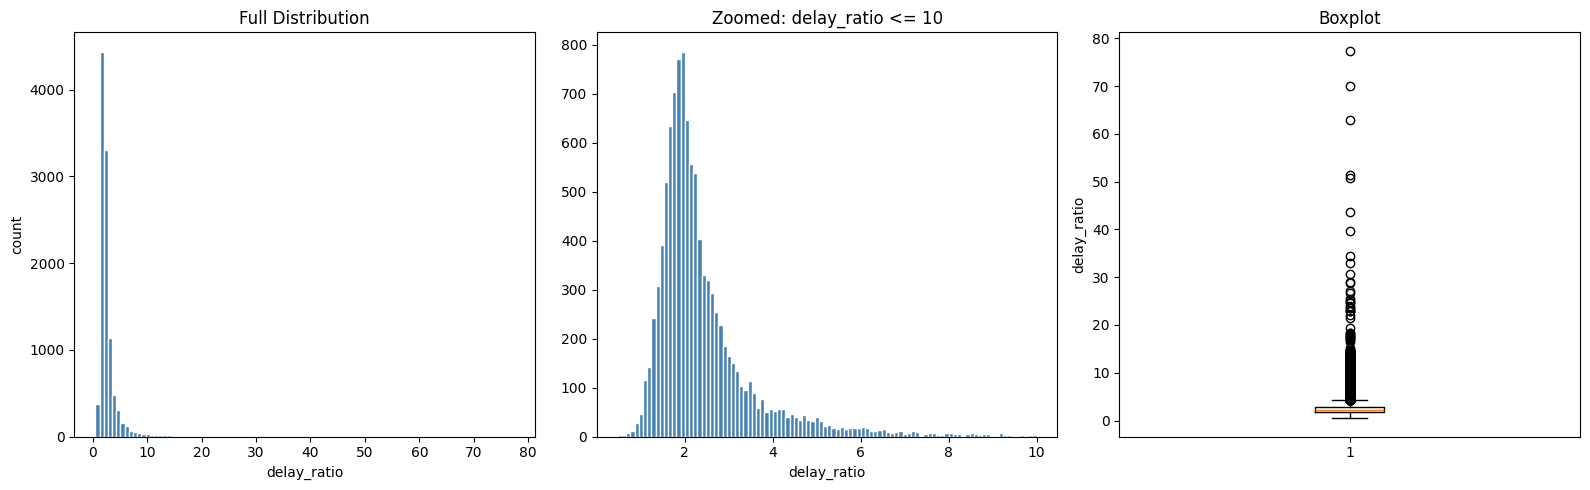

90th percentile: 4.07
95th percentile: 5.42
99th percentile: 11.25
99.5th percentile: 13.84
99.9th percentile: 28.81
100th percentile: 77.39


In [55]:
plot_trip = trip_df.copy()
plot_trip['delay_ratio'] = plot_trip['total_actual_time'] / plot_trip['total_osrm_time']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(plot_trip['delay_ratio'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Full Distribution')
axes[0].set_xlabel('delay_ratio')
axes[0].set_ylabel('count')

axes[1].hist(plot_trip[plot_trip['delay_ratio'] <= 10]['delay_ratio'], bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Zoomed: delay_ratio <= 10')
axes[1].set_xlabel('delay_ratio')

axes[2].boxplot(plot_trip['delay_ratio'])
axes[2].set_title('Boxplot')
axes[2].set_ylabel('delay_ratio')

plt.tight_layout()
plt.show()

for p in [90, 95, 99, 99.5,99.9, 100]:
    print(f'{p}th percentile: {plot_trip["delay_ratio"].quantile(p/100):.2f}')

### Definitely are!!!

In [54]:
trip_df

,trip_uuid,route_type,origin,destination,total_actual_time,total_osrm_time,total_distance,hour_of_day,day_of_week,is_weekend,time_bin
0,trip-153671041653548748,FTL,IND209304AAA,IND209304AAA,1562.0,717.0,824.732854,16,2,0,midday
1,trip-153671042288605164,Carting,IND561203AAB,IND561203AAB,143.0,68.0,73.186911,2,2,0,overnight
2,trip-153671043369099517,FTL,IND000000ACB,IND000000ACB,3347.0,1740.0,1927.404273,3,4,0,overnight
3,trip-153671046011330457,Carting,IND400072AAB,IND401104AAA,59.0,15.0,17.175274,0,2,0,overnight
4,trip-153671052974046625,FTL,IND583101AAA,IND583119AAA,341.0,117.0,127.448500,0,2,0,overnight
...,...,...,...,...,...,...,...,...,...,...,...
10649,trip-153800579708680929,Carting,IND390022AAA,IND388320AAA,47.0,26.0,33.876461,23,2,0,overnight
10650,trip-153800585467019097,Carting,IND614620AAA,IND623407AAA,305.0,163.0,174.336373,3,3,0,overnight
10651,trip-153800603160412602,FTL,IND423106AAA,IND423106AAA,186.0,93.0,103.789477,1,3,0,overnight
10652,trip-153800605670819251,FTL,IND205001AAB,IND207247AAB,627.0,329.0,235.890506,23,2,0,overnight


In [56]:
trip_df['delay_ratio'] = trip_df['total_actual_time'] / trip_df['total_osrm_time']
Q1 = trip_df['delay_ratio'].quantile(0.25)
Q3 = trip_df['delay_ratio'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower:.2f}")
print(f"Upper Bound: {upper:.2f}")
print(f"Trips that would be removed: {((trip_df['delay_ratio'] < lower) | (trip_df['delay_ratio'] > upper)).sum()}")
print(f"Trips that would remain: {((trip_df['delay_ratio'] >= lower) & (trip_df['delay_ratio'] <= upper)).sum()}")

Q1: 1.75
Q3: 2.75
IQR: 0.99
Lower Bound: 0.26
Upper Bound: 4.24
Trips that would be removed: 963
Trips that would remain: 9691


In [57]:
trip_df = trip_df[(trip_df['delay_ratio'] >= lower) & (trip_df['delay_ratio'] <= upper)].reset_index(drop=True)
print(trip_df.shape)

(9691, 12)


In [60]:
segment_df.head()

,segment_key,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,segment_actual_time,segment_osrm_time,segment_osrm_distance,hour_of_day,day_of_week,is_weekend,time_bin,cumulative_actual_time,cumulative_osrm_time,cumulative_osrm_dist
0,trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,20.0,10.0,15.0693,16,2,0,midday,728.0,534.0,670.6205
1,trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),...,22.0,3.0,5.3898,0,2,0,overnight,820.0,474.0,649.8528
2,trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),...,15.0,7.0,6.9464,2,2,0,overnight,46.0,26.0,28.1995
3,trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),...,20.0,3.0,3.8074,0,2,0,overnight,95.0,39.0,55.9899
4,trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),...,275.0,28.0,32.8506,3,4,0,overnight,608.0,231.0,317.7408


#### Edge weights calculation

In [61]:
segment_df['delay_ratio'] = segment_df['actual_time'] / segment_df['osrm_time']

edge_weights = segment_df.groupby(
    ['source_center', 'destination_center', 'route_type', 'time_bin']
)['delay_ratio'].median().reset_index()

edge_weights.rename(columns={'delay_ratio': 'edge_weight'}, inplace=True)

print(edge_weights.shape)
print(edge_weights.head(10))

(3554, 5)
  source_center destination_center route_type      time_bin  edge_weight
0  IND000000AAL       IND411033AAA    Carting  evening_peak     2.083333
1  IND000000AAL       IND411033AAA    Carting        midday     2.600000
2  IND000000AAL       IND411033AAA    Carting  morning_peak     3.384615
3  IND000000AAL       IND411033AAA    Carting     overnight     2.080000
4  IND000000AAS       IND783370AAC        FTL  evening_peak     2.666667
5  IND000000AAS       IND783370AAC        FTL        midday     1.766667
6  IND000000AAZ       IND444203AAA        FTL     overnight     6.020833
7  IND000000AAZ       IND444303AAA        FTL  morning_peak     4.000000
8  IND000000ABA       IND683565AAA    Carting     overnight     1.000000
9  IND000000ABD       IND562132AAA        FTL  morning_peak     1.681941


In [62]:
edge_weights.describe()

,edge_weight
count,3554.000000
mean,2.639007
std,2.776492
min,0.459846
25%,1.710509
50%,2.062076
75%,2.678242
max,70.000000


In [63]:
Q1_ew = edge_weights['edge_weight'].quantile(0.25)
Q3_ew = edge_weights['edge_weight'].quantile(0.75)
IQR_ew = Q3_ew - Q1_ew
upper_ew = Q3_ew + 1.5 * IQR_ew

print(f'Upper bound for edge weights: {upper_ew:.2f}')
print(f'Corridors that would be removed: {(edge_weights["edge_weight"] > upper_ew).sum()}')

edge_weights = edge_weights[edge_weights['edge_weight'] <= upper_ew].reset_index(drop=True)
print(f'Final edge_weights shape: {edge_weights.shape}')

Upper bound for edge weights: 4.13
Corridors that would be removed: 308
Final edge_weights shape: (3246, 5)


In [64]:
# Save processed datasets

segment_df.to_parquet(
    "../data/processed/segment_df.parquet",
    index=False
)

trip_df.to_parquet(
    "../data/processed/trip_df.parquet",
    index=False
)

edge_weights.to_parquet(
    "../data/processed/edge_weights.parquet",
    index=False
)

print("Saved all processed datasets")

Saved all processed datasets
